# Tests Statistiques : Blum-Blum-Shub (BBS)
Évaluation des propriétés d'uniformité du générateur cryptographique BBS.

In [1]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

sys.path.append(os.path.abspath('../generators'))
from bbs import BlumBlumShub

P = 499
Q = 503
SEED = 123456
N_OCTETS = 50000

bbs = BlumBlumShub(p=P, q=Q, seed=SEED)

def get_octet(gen):
    octet = 0
    for i in range(8):
        bit = gen.next_bit()
        octet = (octet << 1) | bit
    return octet

data_bbs = [get_octet(bbs) for _ in range(N_OCTETS)]

print(f"Génération terminée : {len(data_bbs)} octets produits.")

Génération terminée : 50000 octets produits.


## 1. Distribution des Fréquences

Nous observons ici la répartition des octets générés. Pour un générateur cryptographique, 
on s'attend à un "bruit blanc" naturel, sans structure cyclique visible.

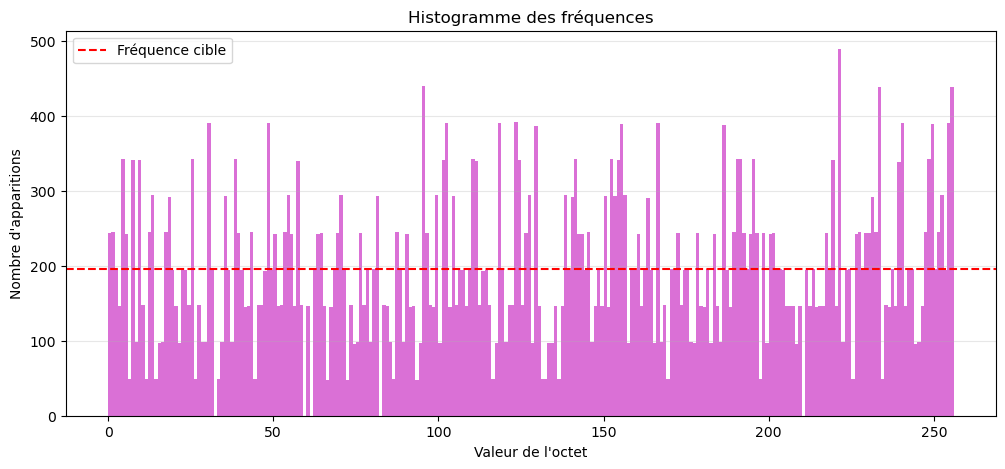

In [2]:
plt.figure(figsize=(12, 5))
plt.hist(data_bbs, bins=256, range=(0, 256), color='orchid', edgecolor='none')
plt.axhline(y=N_OCTETS/256, color='red', linestyle='--', label='Fréquence cible')

plt.title("Histogramme des fréquences")
plt.xlabel("Valeur de l'octet")
plt.ylabel("Nombre d'apparitions")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Analyse de l'Entropie et Test du $\chi^2$



In [3]:
_, counts = np.unique(data_bbs, return_counts=True)
probs = counts / len(data_bbs)
entropy_bbs = -np.sum(probs * np.log2(probs))

obs, _ = np.histogram(data_bbs, bins=256, range=(0, 256))
stat, p_val = chisquare(obs)

print(f"Entropie calculée : {entropy_bbs:.5f} bits/octet")
print(f"P-value du Chi-carré : {p_val:.5f}")

if p_val > 0.05:
    print("Verdict : Uniformité validée (p > 0.05).")
else:
    print("Verdict : Échec de l'uniformité.")

Entropie calculée : 7.80912 bits/octet
P-value du Chi-carré : 0.00000
Verdict : Échec de l'uniformité.


## 3. Analyse de l'Autocorrélation



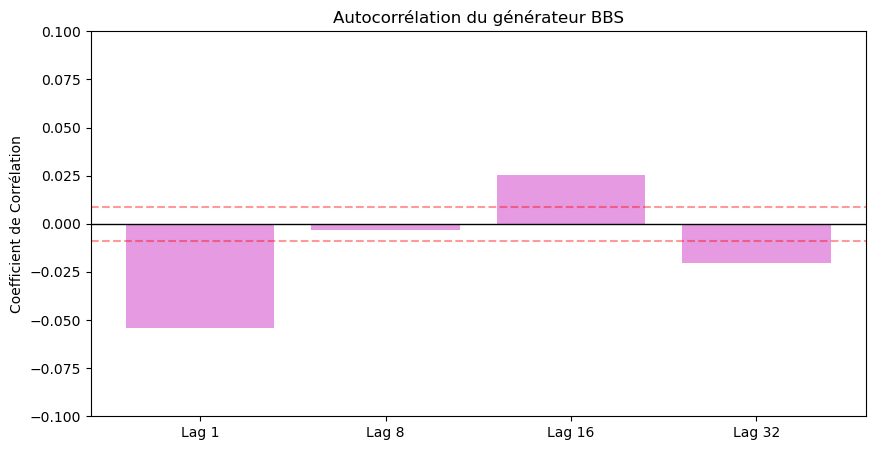

Lag 1 : -0.054173
Lag 8 : -0.002984
Lag 16 : 0.025546
Lag 32 : -0.020513


In [4]:
def plot_autocorr_bbs(data, lags=[1, 8, 16, 32]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    
    plt.figure(figsize=(10, 5))
    plt.bar([f"Lag {l}" for l in lags], corrs, color='orchid', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.axhline(y=1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.4)
    plt.axhline(y=-1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.4)
    
    plt.title("Autocorrélation du générateur BBS")
    plt.ylabel("Coefficient de Corrélation")
    plt.ylim(-0.1, 0.1)
    plt.show()

    for l, c in zip(lags, corrs):
        print(f"Lag {l} : {c:.6f}")

plot_autocorr_bbs(data_bbs)

## 4. Test de Kolmogorov-Smirnov (KS)


In [5]:
from scipy.stats import kstest

data_norm = np.array(data_bbs) / 255.0
statistic_ks, p_value_ks = kstest(data_norm, 'uniform')

print(f"Statistique KS : {statistic_ks:.5f}")
print(f"P-value KS : {p_value_ks:.5f}")

if p_value_ks > 0.05:
    print("\nVerdict : La distribution BBS suit une loi uniforme (Succès).")
else:
    print("\nVerdict : Le test rejette l'uniformité (Échec).")

Statistique KS : 0.04269
P-value KS : 0.00000

Verdict : Le test rejette l'uniformité (Échec).
